In [1]:
%matplotlib inline
# tag: remove-cell applied

# Continuous Data with Bayesian Model Averaging

## Table of Contents

- [Single model fit - LOUD](#single-model-fit---loud)
- [Multiple model fit (sessions) - LOUD](#multiple-model-fit-sessions---loud)
- [Running expanded suite analyses](#running-expanded-suite-analyses)

Bayesian model averaging is currently available for continuous datasets in `pybmds`using the Bayesian LOUD 
(Leveraging Objective Univariate Distributions) method.  Here, we describe how to run a continuous 
analysis using a single model, or model averaging using the standard BMDS suite of models or the expanded suite using PROAST or EFSA models.  Additionally, we demonstrate how to plot your results. 

## Single model fit - LOUD

You can run individual models using the Bayesian LOUD approach rather than running all models and finding the model average.

To run the Exponential 5 model: 

     Exponential 5 Model      
══════════════════════════════

Version: pybmds 25.2 (bmdscore 25.2)

Input Summary:
╒══════════════════════════════╤════════════════════════════╕
│ BMR                          │ 1.0 Standard Deviation     │
│ Distribution                 │ Normal + Constant variance │
│ Modeling Direction           │ Up (↑)                     │
│ Confidence Level (one sided) │ 0.95                       │
│ Modeling Approach            │ Bayesian                   │
╘══════════════════════════════╧════════════════════════════╛

Parameter Settings:
╒═════════════╤════════════════╤════════════════════════════════════════════════════════════╕
│ Parameter   │ Distribution   │ Definition                                                 │
╞═════════════╪════════════════╪════════════════════════════════════════════════════════════╡
│ m0          │ Student_t      │ df=19.0, loc=6.0, scale=0.917662935482247                  │
│ m1          │ Student_t      │ df=19.0, loc=30.0, s

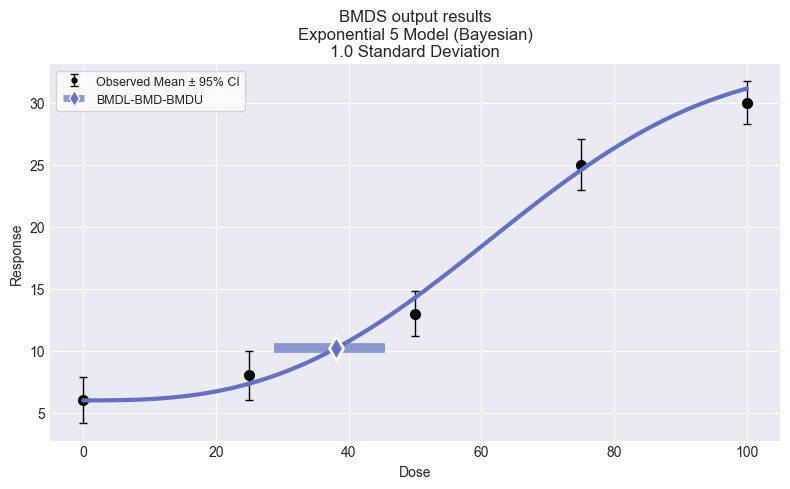

In [14]:
import pybmds
from pybmds.models import continuous

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# Single model fit using LOUD model averaging 
model = continuous.ExponentialM5(
    dataset=dataset,
    settings={
        "priors": pybmds.PriorClass.bayesian_loud,
        "seed": 123,
    },
)

model.execute()

print(model.text())
fig = model.plot()

## Multiple model fit (sessions) - LOUD

To run LOUD Bayesian model averaging for continuous data using the standard BMDS suite of models, chainging the default MCMC settings to chains = 4, iterations/chain = 12,500, and burn-in/chain = 1,250:

BMD = 37.67 [28.46, 44.87]


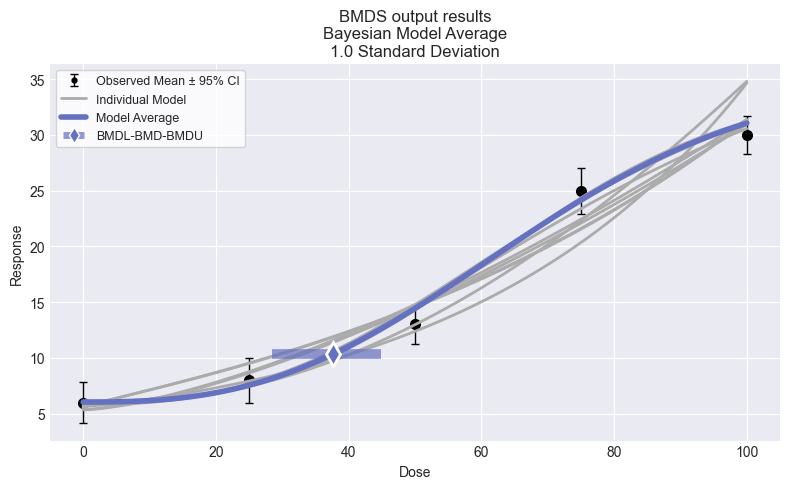

In [15]:
import pybmds

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# LOUD model averaging using the standard BMDS continuous suite
session1 = pybmds.Session(dataset=dataset)

settings = {
    "n_chains": 4,
    "samples": 7500,
    "burnin": 1500,
    "seed": 123,
}

session1.add_default_bayesian_models(
    settings=settings,
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=False,  # standard suite only (not PROAST/EFSA-expanded)
)
session1.execute()

# summarize model-averaged result
res1 = session1.model_average.results
print(f"BMD = {res1.bmd:.2f} [{res1.bmdl:.2f}, {res1.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig1 = session1.plot(colorize=False)

confirm the MCMC settings:

In [16]:
model = session1.models[0]  # or whichever model you want to inspect
print("samples:", model.settings.samples)
print("burnin:", model.settings.burnin)
print("n_chains:", model.settings.n_chains)
print("seed:", model.settings.seed)

samples: 7500
burnin: 1500
n_chains: 4
seed: 123


To print the model average distribution plot and BMD distribution overlay plot:

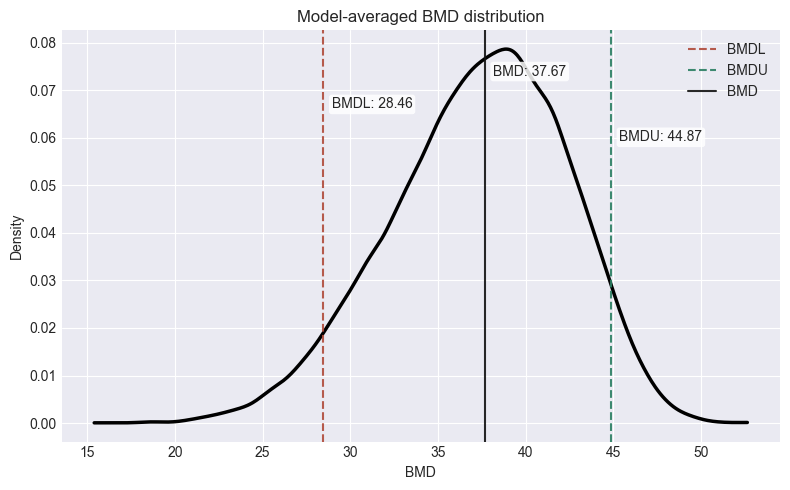

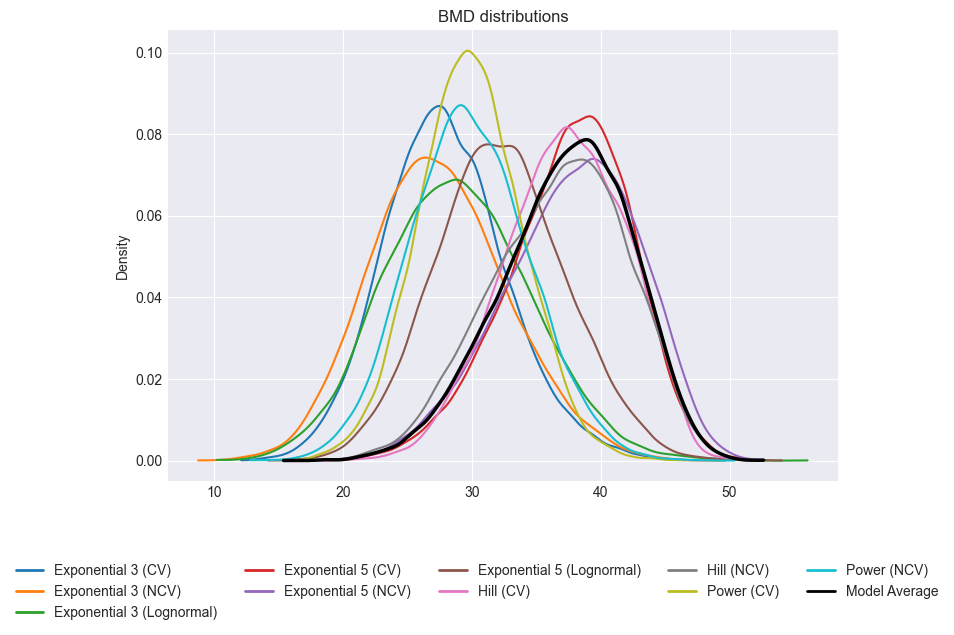

In [17]:
from pybmds.plotting.LOUD import get_model_average_figures
from IPython.display import display

figs1 = get_model_average_figures(session1, compressed=True)


To print the trace plots for an individual model:

Trace plot for: Exponential 5 (CV)


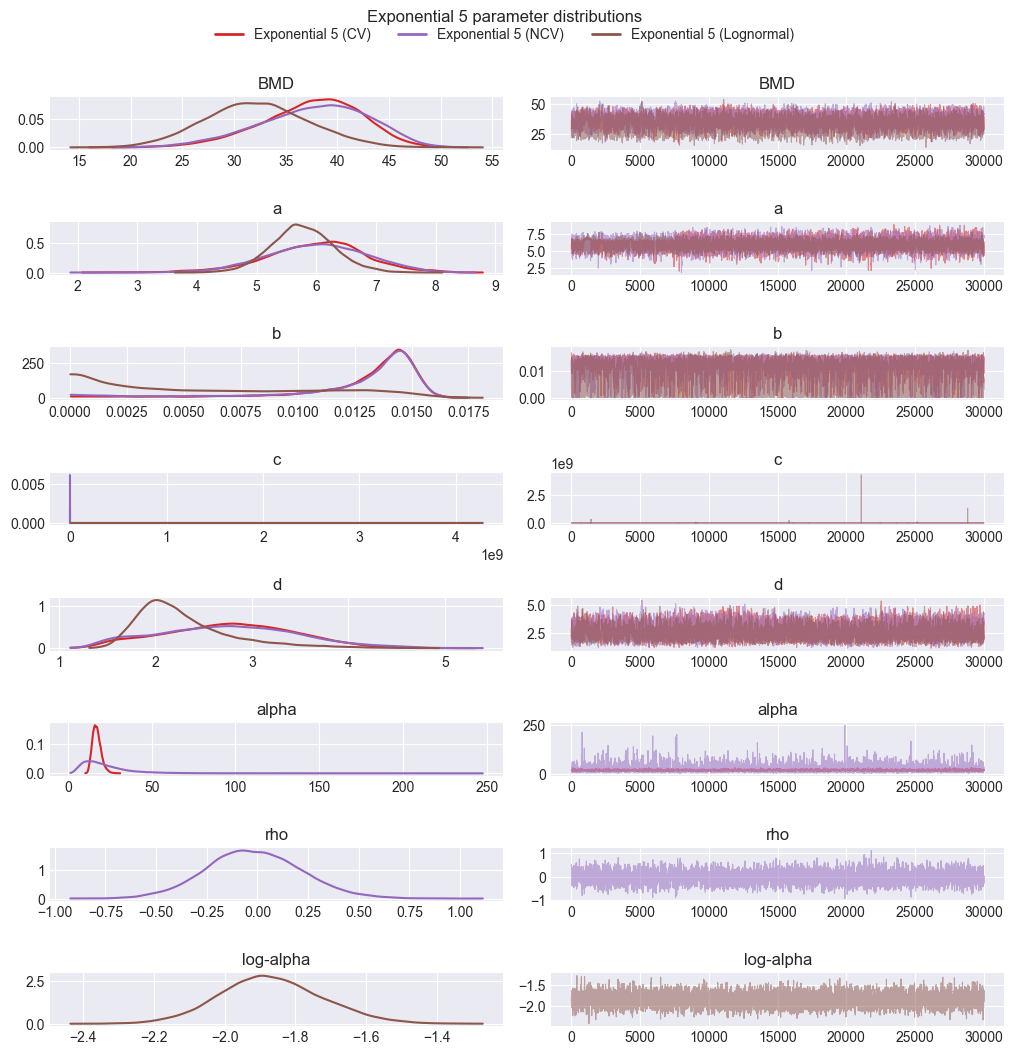

In [18]:
target_model = "Exponential 5 (CV)"

for group in figs1["parameter_groups"]:
    if target_model in group["model_names"]:
        print("Trace plot for:", target_model)
        display(group["trace_figure"])
        break

To print out the MCMC summary table for model-specific BMDs:

In [19]:
display(figs1["bmd_summary"])

,BMD,Median Absolute Deviation,BMDL,BMDU,R-hat,Markov Chain Standard Error (Median),Bulk Effective Sample Size,Tail Effective Sample Size
model,,,,,,,,
Exponential 3 (CV),27.713742,3.130151,20.524160,36.144611,1.000553,0.077312,3532.538539,3635.102721
Exponential 3 (NCV),27.202288,3.598425,19.070434,36.698632,1.000653,0.091618,3348.843936,5021.118557
Exponential 3 (Lognormal),28.753017,3.874337,19.909502,38.464278,1.001270,0.081926,4395.546505,5298.778052
Exponential 5 (CV),37.924254,3.231709,28.936213,44.696075,1.006425,0.126516,1542.903105,2242.326970
Exponential 5 (NCV),38.134441,3.654316,28.307410,45.694360,1.004580,0.158786,1172.210400,1520.564045
Exponential 5 (Lognormal),32.109926,3.387915,24.106652,40.752937,1.000798,0.105221,2488.299744,2788.053360
Hill (CV),37.366370,3.324887,29.125125,44.623682,1.009036,0.163747,933.789853,1076.216157
Hill (NCV),37.100968,3.691206,27.619137,44.755811,1.023774,0.302109,307.355853,940.821396
Power (CV),29.812821,2.672861,23.409475,36.521412,1.001856,0.064351,3658.890422,5200.650325


To display a summary table of results without MCMC output:

In [20]:
from IPython.display import display

bayes_summary1 = (
session1.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df1 = bayes_summary1
display(df1)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Power (CV),0.1,0.005524,23.409475,29.812821,36.521412,0.654874,-0.730541
1,Power (NCV),0.1,0.006110,22.484969,29.700620,37.650516,0.647174,-0.717251
2,Hill (CV),0.1,0.220993,29.125125,37.366370,44.623682,-0.005627,0.592656
3,Hill (NCV),0.1,0.106371,27.619137,37.100968,44.755811,0.034109,0.427376
4,Exponential 3 (CV),0.1,0.000100,20.524160,27.713742,36.144611,0.488212,-1.507549
5,Exponential 3 (NCV),0.1,0.000130,19.070434,27.202288,36.698632,0.489941,-1.477439
6,Exponential 3 (Lognormal),0.1,0.000231,19.909502,28.753017,38.464278,-0.257044,-0.792491
7,Exponential 5 (CV),0.1,0.433928,28.936213,37.924254,44.696075,-0.044534,-1.371802
8,Exponential 5 (NCV),0.1,0.222099,28.307410,38.134441,45.694360,-0.028423,-1.510050
9,Exponential 5 (Lognormal),0.1,0.004513,24.106922,32.110365,40.752724,-0.390961,0.281088


### Running Expanded Suite analyses

To run LOUD Bayesian model averaging for continuous data using the expanded suite of models (i.e., BMDS + PROAST + EFSA models) and the same changes to the MCMC settings:

BMD = 43.03 [31.77, 48.31]


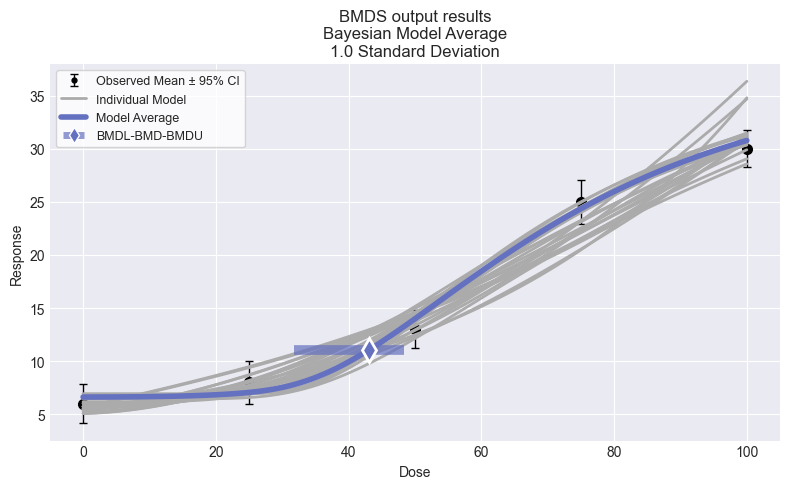

In [21]:
# LOUD model averaging using the expanded BMDS/PROAST/EFSA continuous suite
session2 = pybmds.Session(dataset=dataset)

settings = {
    "n_chains": 4,
    "samples": 12500,
    "burnin": 1250,
    "seed": 123,
}

session2.add_default_bayesian_models(
    settings=settings,
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=True,  # expanded BMDS/PROAST/EFSA suite  
)
session2.execute()

# summarize model-averaged result
res2 = session2.model_average.results
print(f"BMD = {res2.bmd:.2f} [{res2.bmdl:.2f}, {res2.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig2 = session2.plot(colorize=False)

And to print out a summary table:

In [22]:
bayes_summary2 = (
session2.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df2 = bayes_summary2
display(df2)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Power (CV),0.043478,0.000684,23.320380,30.020834,37.222193,0.621267,-0.723924
1,Power (NCV),0.043478,0.000803,22.433512,29.743756,37.515730,0.638285,-0.735962
2,Exponential 3 (CV),0.043478,0.000019,20.735498,27.884262,36.077093,0.480743,-1.473752
3,Exponential 3 (NCV),0.043478,0.000026,19.272916,27.462354,36.759717,0.507562,-1.441722
4,Exponential 3 (Lognormal),0.043478,0.000040,20.022366,28.709927,38.495125,-0.269027,-0.801789
5,Exponential 5 (CV),0.043478,0.081537,29.357474,38.251142,45.031109,-0.084482,-1.333397
6,Exponential 5 (NCV),0.043478,0.036270,28.495324,38.153960,45.882031,-0.033337,-1.474722
7,Exponential 5 (Lognormal),0.043478,0.000751,24.205000,32.111892,41.052494,-0.401873,0.247314
8,Multiplicative Hill (CV),0.043478,0.019049,27.363897,35.591911,44.284809,0.340373,0.508337
9,Multiplicative Hill (NCV),0.043478,0.024251,28.091041,37.387241,44.824842,0.006530,0.501154


To run LOUD Bayesian model averaging for continuous data using the just the PROAST and EFSA models:

BMD = 43.03 [32.08, 48.44]


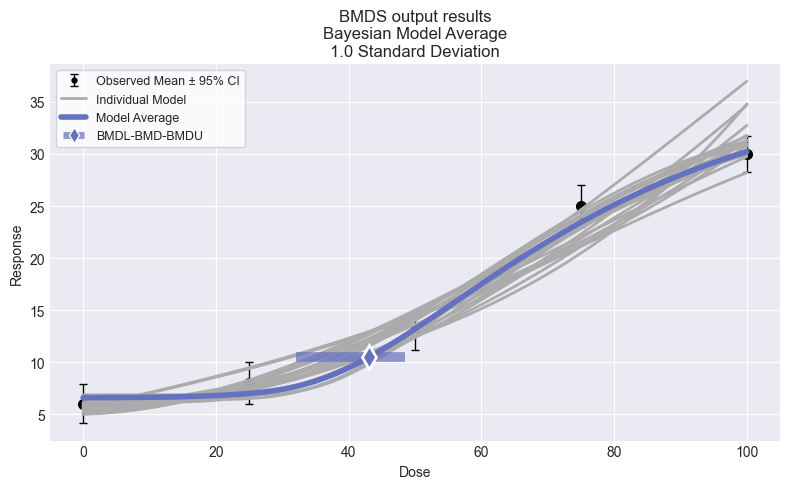

In [23]:
# dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

session3 = pybmds.Session(dataset=dataset)

# Expanded models only (PROAST/EFSA-style set), LOUD priors
expanded_models = [
    pybmds.Models.ExponentialM3,
    pybmds.Models.ExponentialM5,
    pybmds.Models.MultiplicativeHill,
    pybmds.Models.InverseExponential,
    pybmds.Models.Lognormal,
    pybmds.Models.ContinuousGamma,
    pybmds.Models.LMS2,
]

# add all three disttypes (example: constant variance)
dist_types = [
    pybmds.ContinuousDistType.normal,
    pybmds.ContinuousDistType.normal_ncv,
    pybmds.ContinuousDistType.log_normal,
]

for model_name in expanded_models:
    for dt in dist_types:
        session3.add_model(
            model_name,
            settings={
                "n_chains": 4,
                "samples": 12500,
                "burnin": 1250,
                "seed": 123,
                "priors": pybmds.PriorClass.bayesian_loud,
                "disttype": dt,
            },
        )

session3.add_model_averaging()
session3.execute()

res3 = session3.model_average.results
print(f"BMD = {res3.bmd:.2f} [{res3.bmdl:.2f}, {res3.bmdu:.2f}]")
fig3 = session3.plot(colorize=False)

To print a summary table for the EFSA and PROAST models:

In [24]:
bayes_summary3 = (
session3.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df3 = bayes_summary3
display(df3)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Exponential 3 (CV),0.047619,0.000020,20.735498,27.884262,36.077093,0.480743,-1.473752
1,Exponential 3 (NCV),0.047619,0.000027,19.272916,27.462354,36.759717,0.507562,-1.441722
2,Exponential 3 (Lognormal),0.047619,0.000041,20.022366,28.709927,38.495125,-0.269027,-0.801789
3,Exponential 5 (CV),0.047619,0.084813,29.357474,38.251142,45.031109,-0.084482,-1.333397
4,Exponential 5 (NCV),0.047619,0.037728,28.495324,38.153960,45.882031,-0.033337,-1.474722
5,Exponential 5 (Lognormal),0.047619,0.000781,24.205000,32.111892,41.052494,-0.401873,0.247314
6,Multiplicative Hill (CV),0.047619,0.031450,28.544793,36.488247,44.423208,0.127951,0.527546
7,Multiplicative Hill (NCV),0.047619,0.012766,27.035375,36.588446,44.145742,0.112514,0.459696
8,Multiplicative Hill (Lognormal),0.047619,0.000756,23.301830,31.206884,39.892231,-0.443085,0.225538
9,Inverse Exponential (CV),0.047619,0.329281,38.289285,44.476539,48.759159,-0.967364,-0.541459


To compare the model averaged results for all three analyses using different model suites:

In [25]:
import pandas as pd

def ma_point_summary(session, label):
    if session.model_average is None:
        raise ValueError(f"{label} has no model average.")
    r = session.model_average.results
    return {
        "Session": label,
        "BMDL": float(r.bmdl),
        "BMD": float(r.bmd),
        "BMDU": float(r.bmdu),
    }

comparison = pd.DataFrame([
    ma_point_summary(session1, "Session 1 (BMDS only)"),
    ma_point_summary(session2, "Session 2 (BMDS + Expanded)"),
    ma_point_summary(session3, "Session 3 (Expanded only)"),
])

comparison

,Session,BMDL,BMD,BMDU
0,Session 1 (BMDS only),28.460401,37.669465,44.869556
1,Session 2 (BMDS + Expanded),31.768329,43.033486,48.313121
2,Session 3 (Expanded only),32.081067,43.030945,48.440645
